## Aim : To build a text classification model using Logistic Regression to classify Movie Reviews

## Sentiment Analysis using Logistic Regression

In [230]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [231]:
# Prepare dummy text data and their corresponding labels (0 = Negative, 1 = Positive)
corpus = [
    "What a complete waste of time and money.",                  
    "Brilliant acting, loved every minute from start to finish.",
    "Superb script and incredible performances by everyone.",    
    "Avoid this film, it is a complete disaster.",              
    "The plot was incredibly boring, slow, and dry.",            
    "Truly enjoyable, funny, and deeply touching experience.",   
    "Deeply moving and masterfully written story.",              
    "I hated the ending, it made no sense at all.",              
    "Disappointing execution with weak and boring characters.",  
    "It was a masterfully crafted story and great acting.",      
    "I absolutely love this movie, it was fantastic!",           
    "Worst experience ever, terrible writing and awful plot.",   
    "An absolute joy to watch, wonderful and engaging.",         
    "A total disaster, terrible directing and horrible acting.", 
    "A frustrating, predictable, and completely dull movie.",    
    "Highly recommended! One of the best films this year.",      
    "The performance was terrible, dry, and uninspiring.",       
    "A wonderful film with fantastic direction and great visuals.", 
    "Completely overrated, dry performance, and badly edited.",  
    "I thoroughly enjoyed the characters and the plot.",         
    "Terrible script, boring storyline, and waste of money.",    
    "Captivating performance, highly recommended to all.",       
    "Amazing acting and a brilliant storyline.",                 
    "I hated everything about this, slow and predictable.",       
    "Great movie, fantastic script and amazing ending.",         
    "Horrible dialogue, poor pacing, and awful acting.",         
    "Outstanding storyline, one of my favorite movies ever.",    
    "I could barely stay awake, totally uninteresting and bad.", 
    "Excellent performance, truly a masterpiece of modern cinema.", 
    "Awful experience, I would not recommend it to anyone."      
]

In [232]:
labels = [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0]

In [233]:
# Split the dataset into training sets (80%) & testing sets (20%)
X_train, X_test, y_train, y_test = train_test_split(corpus,labels,
                                                    test_size = 0.22,
                                                    random_state = 42)

In [234]:
# Convert raw text into numerical TF-IDF feature vectors
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [235]:
# Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [236]:
# Evaluate the model performance on the test set
predictions = model.predict(X_test_tfidf)
print(f"Model Accuracy : {accuracy_score(y_test, predictions) * 100:.2f}%")

Model Accuracy : 85.71%


In [237]:
# Predict sentiment on completely new sample santences
new_samples = [
    "It was a masterfully crafted story.",
    "The performance was terrible and dry."
]

new_samples_tfidf = vectorizer.transform(new_samples)
new_predictions = model.predict(new_samples_tfidf)

In [238]:
for doc, pred in zip(new_samples, new_predictions):
    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"Review : '{doc}' -> Predicted Sentiment: {sentiment}")

Review : 'It was a masterfully crafted story.' -> Predicted Sentiment: Positive
Review : 'The performance was terrible and dry.' -> Predicted Sentiment: Negative


## Visualization

In [239]:
# 1. Get prediction confidence percentages (probabilities)
probabilities = model.predict_proba(new_samples_tfidf)

In [240]:
# 2. Setup labels and probabilities
sample_names = ['Sample 1\n(Positive)', 'Sample 2\n(Negative)']
pos_probs = probabilities[:, 1]  # Probability of Positive (1)
neg_probs = probabilities[:, 0]  # Probability of Negative (0)
x = np.arange(len(sample_names))
width = 0.35

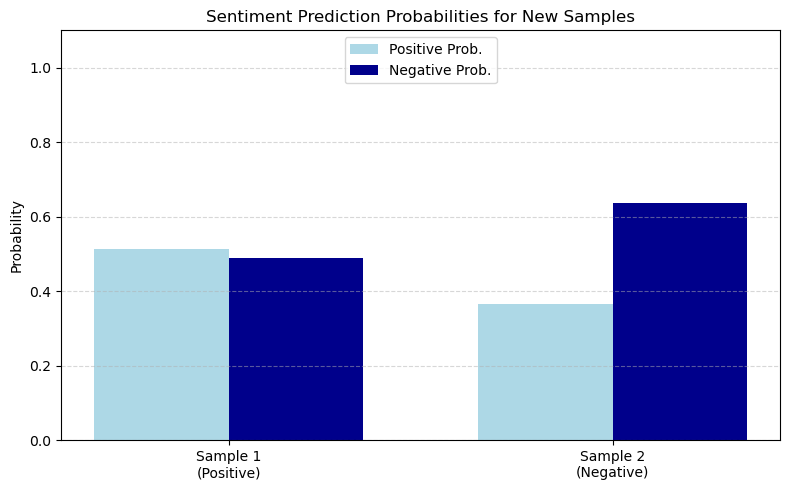

In [241]:
# 3. Create Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pos_probs, width, label='Positive Prob.', color='lightblue')
plt.bar(x + width/2, neg_probs, width, label='Negative Prob.', color='darkblue')
# 4. Styling
plt.ylabel('Probability')
plt.title('Sentiment Prediction Probabilities for New Samples')
plt.xticks(x, sample_names)
plt.ylim(0, 1.1)
plt.legend(loc='upper center')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()